## Detección del número 1 en MNIST mediante Aprendizaje por Refuerzo con REINFORCE

Desarrollar en Python y PyTorch un agente que analice imágenes de MNIST y decida si corresponden al número 1 o no. El agente recibe una recompensa de +1 cuando acierta y -1 cuando se equivoca, se entrena con el algoritmo REINFORCE y debe mostrar al final su precisión, recompensa promedio y algunas imágenes identificadas como número 1.

### Librerias

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.distributions import Categorical
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms


### Configuracion

In [ ]:
SEMILLA = 42
EPOCAS = 5
BATCH_SIZE = 128
LEARNING_RATE = 0.001

# Recompensas del agente
RECOMPENSA_CORRECTA = 1.0
RECOMPENSA_INCORRECTA = -1.0

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

dispositivo = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo utilizado:", dispositivo)


Dispositivo utilizado: cpu


### Descargar la base de datos MNIST

In [ ]:
transformacion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

datos_entrenamiento = datasets.MNIST(
    root="./datos",
    train=True,
    download=True,
    transform=transformacion
)

datos_prueba = datasets.MNIST(
    root="./datos",
    train=False,
    download=True,
    transform=transformacion
)

print("Imágenes de entrenamiento:", len(datos_entrenamiento))
print("Imágenes de prueba:", len(datos_prueba))

100%|██████████| 9.91M/9.91M [00:00<00:00, 24.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 605kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.86MB/s]

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000


### Balancear los numeros 1 y los que no son 1

In [ ]:
# Convertir las etiquetas:
# 1 = es el número 1
# 0 = no es el número 1

etiquetas_binarias = (
    datos_entrenamiento.targets == 1
).long()

cantidad_unos = int(etiquetas_binarias.sum())
cantidad_no_unos = len(etiquetas_binarias) - cantidad_unos

print("Cantidad de números 1:", cantidad_unos)
print("Cantidad de números diferentes de 1:", cantidad_no_unos)

# Se balancean los datos para evitar que el agente
# aprenda simplemente a responder siempre "no es 1"

peso_unos = 1.0 / cantidad_unos
peso_no_unos = 1.0 / cantidad_no_unos

pesos = torch.where(
    etiquetas_binarias == 1,
    torch.tensor(peso_unos),
    torch.tensor(peso_no_unos)
)

muestreador = WeightedRandomSampler(
    weights=pesos,
    num_samples=20000,
    replacement=True
)

cargador_entrenamiento = DataLoader(
    datos_entrenamiento,
    batch_size=BATCH_SIZE,
    sampler=muestreador
)

cargador_prueba = DataLoader(
    datos_prueba,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Cantidad de números 1: 6742
Cantidad de números diferentes de 1: 53258


### Crear el agente

In [ ]:
class AgenteRL(nn.Module):

    def __init__(self):
        super().__init__()

        self.red = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),

            # Dos acciones:
            # 0 = no es un 1
            # 1 = sí es un 1
            nn.Linear(64, 2)
        )

    def forward(self, imagen):
        return self.red(imagen)


agente = AgenteRL().to(dispositivo)

optimizador = optim.Adam(
    agente.parameters(),
    lr=LEARNING_RATE
)

### Evaluar el agente

In [ ]:
def evaluar():

    agente.eval()

    correctos = 0
    total = 0

    verdaderos_positivos = 0
    falsos_positivos = 0
    falsos_negativos = 0

    with torch.no_grad():

        for imagenes, etiquetas_originales in cargador_prueba:

            imagenes = imagenes.to(dispositivo)

            # Etiqueta binaria:
            # 1 si el número real es 1
            # 0 para cualquier otro número
            etiquetas = (
                etiquetas_originales == 1
            ).long().to(dispositivo)

            salidas = agente(imagenes)

            acciones = salidas.argmax(dim=1)

            correctos += (
                acciones == etiquetas
            ).sum().item()

            total += etiquetas.size(0)

            verdaderos_positivos += (
                (acciones == 1) & (etiquetas == 1)
            ).sum().item()

            falsos_positivos += (
                (acciones == 1) & (etiquetas == 0)
            ).sum().item()

            falsos_negativos += (
                (acciones == 0) & (etiquetas == 1)
            ).sum().item()

    precision_general = 100 * correctos / total

    precision_unos = verdaderos_positivos / max(
        verdaderos_positivos + falsos_positivos,
        1
    )

    recall_unos = verdaderos_positivos / max(
        verdaderos_positivos + falsos_negativos,
        1
    )

    return (
        precision_general,
        precision_unos * 100,
        recall_unos * 100
    )



### Entrenar con aprendizaje por refuerzo

In [ ]:
def entrenar():

    historial_recompensas = []
    historial_precision = []

    for epoca in range(1, EPOCAS + 1):

        agente.train()

        recompensa_total = 0
        cantidad_total = 0
        aciertos = 0

        for imagenes, etiquetas_originales in cargador_entrenamiento:

            imagenes = imagenes.to(dispositivo)

            # Convertir el problema en:
            # 1 = es el número 1
            # 0 = no es el número 1
            etiquetas = (
                etiquetas_originales == 1
            ).long().to(dispositivo)

            # El agente observa las imágenes
            logits = agente(imagenes)

            # Crear una distribución de probabilidades
            distribucion = Categorical(logits=logits)

            # El agente selecciona una acción
            acciones = distribucion.sample()

            # Calcular la recompensa
            recompensas = torch.where(
                acciones == etiquetas,
                torch.tensor(
                    RECOMPENSA_CORRECTA,
                    device=dispositivo
                ),
                torch.tensor(
                    RECOMPENSA_INCORRECTA,
                    device=dispositivo
                )
            )

            # Probabilidad de las acciones seleccionadas
            log_probabilidades = distribucion.log_prob(
                acciones
            )

            # Baseline para estabilizar el aprendizaje
            ventaja = (
                recompensas - recompensas.mean()
            ).detach()

            # Pérdida del algoritmo REINFORCE
            perdida = -(
                log_probabilidades * ventaja
            ).mean()

            # Favorecer cierta exploración
            entropia = distribucion.entropy().mean()

            perdida = perdida - 0.001 * entropia

            optimizador.zero_grad()
            perdida.backward()
            optimizador.step()

            recompensa_total += recompensas.sum().item()

            aciertos += (
                acciones == etiquetas
            ).sum().item()

            cantidad_total += etiquetas.size(0)

        recompensa_promedio = (
            recompensa_total / cantidad_total
        )

        precision_entrenamiento = (
            100 * aciertos / cantidad_total
        )

        precision_prueba, precision_unos, recall_unos = evaluar()

        historial_recompensas.append(
            recompensa_promedio
        )

        historial_precision.append(
            precision_prueba
        )

        print(
            f"Iteración {epoca}/{EPOCAS} | "
            f"Recompensa: {recompensa_promedio:.3f} | "
            f"Aciertos entrenamiento: {precision_entrenamiento:.2f}% | "
            f"Precisión prueba: {precision_prueba:.2f}% | "
            f"Detección de unos: {recall_unos:.2f}%"
        )

    return historial_recompensas, historial_precision

### Mostrar las imagenes identificadas como numero 1

In [ ]:
def buscar_numeros_uno(cantidad_imagenes=40):

    agente.eval()

    imagenes, etiquetas_originales = next(
        iter(cargador_prueba)
    )

    imagenes_dispositivo = imagenes.to(dispositivo)

    with torch.no_grad():

        salidas = agente(imagenes_dispositivo)

        probabilidades = torch.softmax(
            salidas,
            dim=1
        )

        acciones = probabilidades.argmax(
            dim=1
        ).cpu()

        confianza_uno = probabilidades[
            :, 1
        ].cpu()

    cantidad_imagenes = min(
        cantidad_imagenes,
        len(imagenes)
    )

    columnas = 8
    filas = int(
        np.ceil(cantidad_imagenes / columnas)
    )

    plt.figure(figsize=(16, filas * 2.2))

    encontrados = 0

    for posicion in range(cantidad_imagenes):

        plt.subplot(
            filas,
            columnas,
            posicion + 1
        )

        imagen = imagenes[posicion].squeeze()

        numero_real = etiquetas_originales[
            posicion
        ].item()

        prediccion = acciones[posicion].item()

        confianza = (
            confianza_uno[posicion].item() * 100
        )

        plt.imshow(
            imagen,
            cmap="gray"
        )

        if prediccion == 1:

            encontrados += 1

            plt.title(
                f"ES UN 1\n{confianza:.1f}%",
                color="green",
                fontweight="bold"
            )

            # Borde verde
            for borde in plt.gca().spines.values():
                borde.set_edgecolor("green")
                borde.set_linewidth(4)

        else:

            plt.title(
                "No es 1",
                color="gray"
            )

        plt.axis("off")

    plt.suptitle(
        "Búsqueda del número 1 en MNIST",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

    print(
        f"El agente encontró {encontrados} posibles números 1 "
        f"entre {cantidad_imagenes} imágenes."
    )

### Mostrar los resultados del entrenamiento

In [ ]:
def mostrar_entrenamiento(
    recompensas,
    precisiones
):

    iteraciones = range(
        1,
        len(recompensas) + 1
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    plt.plot(
        iteraciones,
        recompensas,
        marker="o"
    )

    plt.title("Recompensa del agente")
    plt.xlabel("Iteración")
    plt.ylabel("Recompensa promedio")
    plt.grid()

    plt.subplot(1, 2, 2)

    plt.plot(
        iteraciones,
        precisiones,
        marker="o",
        color="green"
    )

    plt.title("Precisión en prueba")
    plt.xlabel("Iteración")
    plt.ylabel("Precisión (%)")
    plt.grid()

    plt.tight_layout()
    plt.show()


### Ejecutar el prgrama

Iteración 1/5 | Recompensa: 0.905 | Aciertos entrenamiento: 95.25% | Precisión prueba: 99.35% | Detección de unos: 94.98%
Iteración 2/5 | Recompensa: 0.962 | Aciertos entrenamiento: 98.08% | Precisión prueba: 99.51% | Detección de unos: 96.39%
Iteración 3/5 | Recompensa: 0.962 | Aciertos entrenamiento: 98.11% | Precisión prueba: 99.43% | Detección de unos: 99.21%
Iteración 4/5 | Recompensa: 0.979 | Aciertos entrenamiento: 98.92% | Precisión prueba: 99.05% | Detección de unos: 99.65%
Iteración 5/5 | Recompensa: 0.981 | Aciertos entrenamiento: 99.06% | Precisión prueba: 99.64% | Detección de unos: 99.38%

RESULTADO FINAL
Precisión general: 99.64%
Precisión al indicar que es 1: 97.49%
Porcentaje de números 1 encontrados: 99.38%


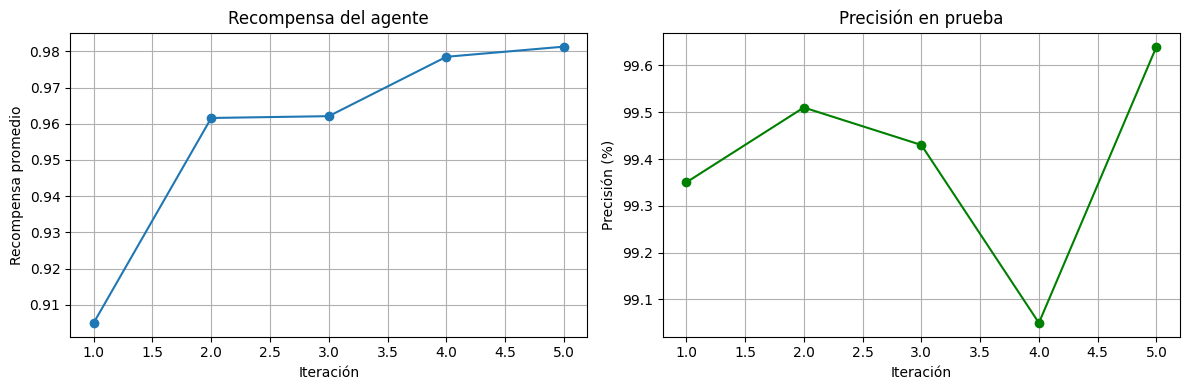

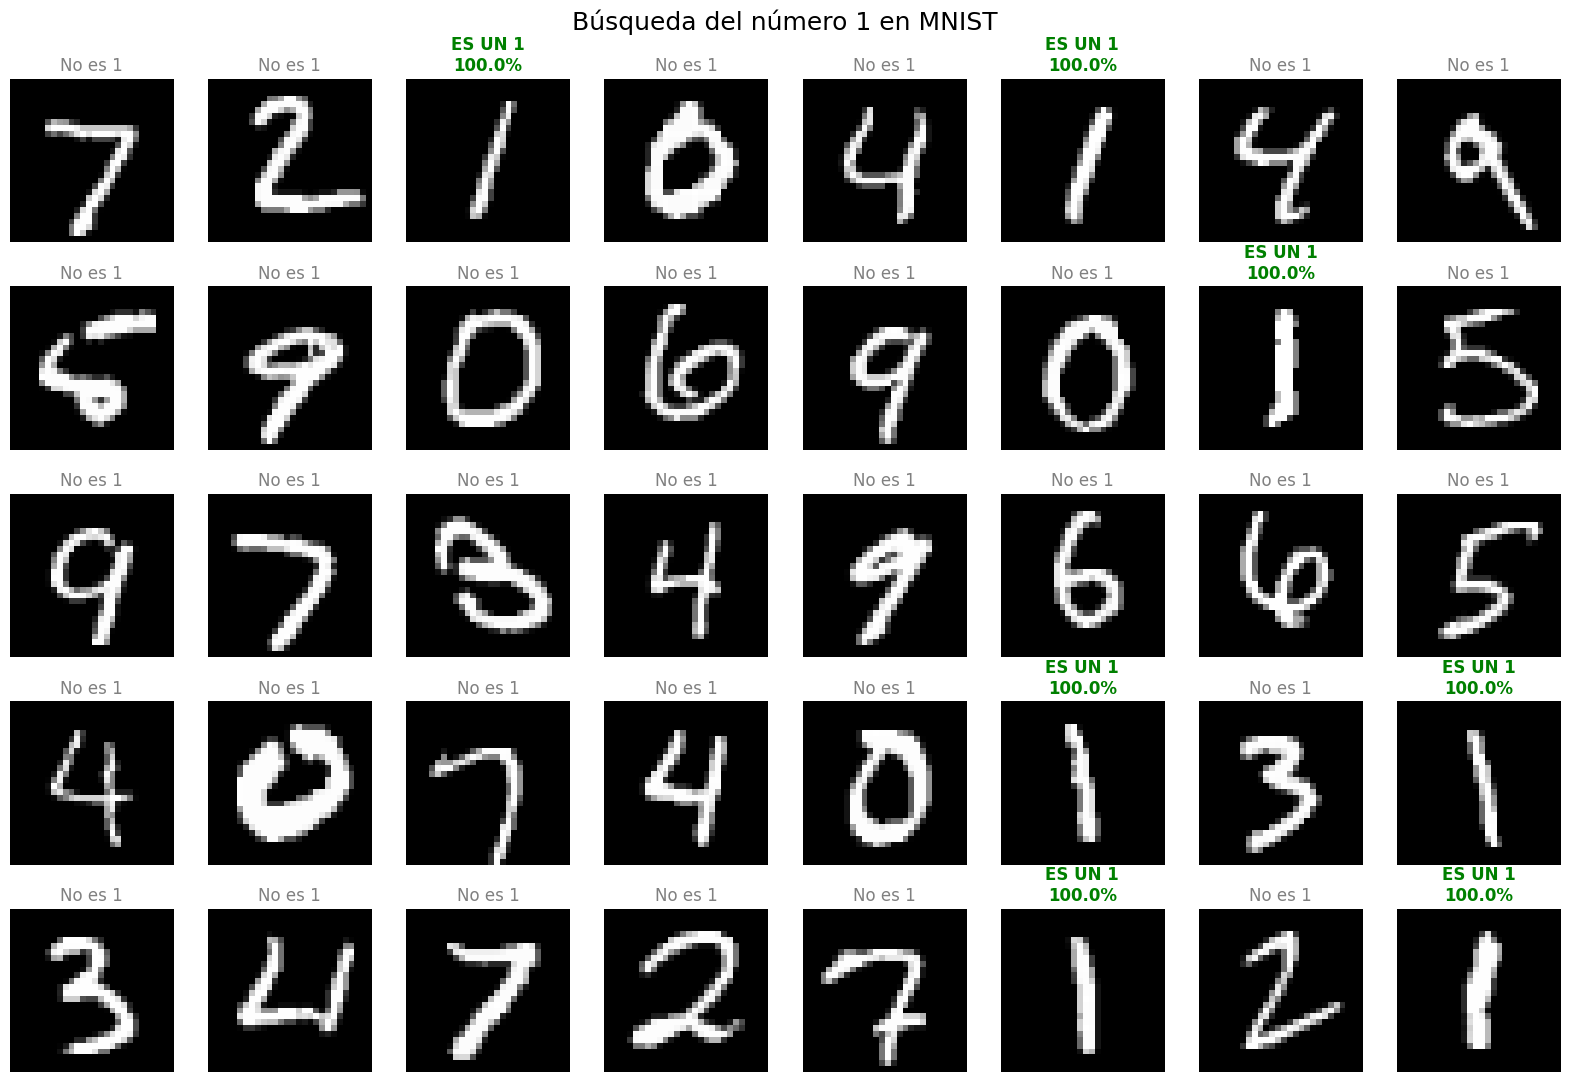

El agente encontró 7 posibles números 1 entre 40 imágenes.


In [ ]:
recompensas, precisiones = entrenar()

precision_general, precision_unos, recall_unos = evaluar()

print("\n" + "=" * 55)
print("RESULTADO FINAL")
print("=" * 55)

print(f"Precisión general: {precision_general:.2f}%")
print(f"Precisión al indicar que es 1: {precision_unos:.2f}%")
print(f"Porcentaje de números 1 encontrados: {recall_unos:.2f}%")

mostrar_entrenamiento(
    recompensas,
    precisiones
)

buscar_numeros_uno(
    cantidad_imagenes=40
)